# 📄 Extracción de artículos completos desde PMC

## 🌍 Contexto

PubMed contiene información sobre millones de artículos científicos — título, resumen, autores, fecha — pero en la mayoría de los casos **no incluye el texto completo** del artículo. Para acceder al contenido íntegro (introducción, métodos, resultados, discusión), necesitamos acudir a otro repositorio: **PMC (PubMed Central)**.

PMC es el archivo de acceso abierto de artículos biomédicos de los NIH (Institutos Nacionales de Salud de EE.UU.). No todos los artículos de PubMed están en PMC — solo aquellos cuyas editoriales permiten la distribución gratuita del texto completo.

La relación entre ambas bases de datos es la siguiente:
- Cada artículo de PubMed tiene un identificador llamado **PMID**
- Si ese artículo también está en PMC, tiene un segundo identificador: **PMCID**
- Podemos cruzar ambos mundos usando el PMID como puente

En este notebook exploramos cómo acceder al texto completo de los artículos a través de PMC y cómo estructurarlo para que pueda complementar la información ya extraída de PubMed.

---

## 🎯 Objetivo

Construir un **parser de artículos completos** que, a partir de un identificador de PMC, descargue el artículo en formato XML y extraiga su contenido estructurado por secciones (introducción, métodos, resultados, discusión).

---

## ⚙️ Estrategia

El texto completo de los artículos en PMC está disponible en un formato llamado **JATS XML** — un estándar para publicaciones científicas. Este formato organiza el artículo en secciones bien definidas, lo que nos permite extraer cada parte de forma independiente.

La estructura objetivo de cada artículo es:
```json
{
    "pmcid": "...",
    "pmid": "...",
    "title": "...",
    "abstract": "...",
    "sections": [
        {"section_title": "Introduction", "text": "..."},
        {"section_title": "Methods", "text": "..."},
        {"section_title": "Results", "text": "..."},
        {"section_title": "Discussion", "text": "..."}
    ]
}
```

---

## 🧩 Pasos que seguimos

### 1. Verificación del enlace PubMed ↔ PMC
Confirmamos que podemos relacionar un PMID de PubMed con su PMCID correspondiente, y entendemos qué artículos tienen texto completo disponible.

### 2. Descarga del artículo en XML
Usando la API de NCBI, descargamos el contenido completo del artículo en formato XML.

### 3. Exploración de la estructura XML
Inspeccionamos el árbol de elementos del XML para entender dónde está cada parte del artículo: título, abstract, secciones del cuerpo principal, referencias, etc.

### 4. Construcción del parser
Implementamos funciones para extraer de forma robusta cada campo relevante, manejando la variabilidad entre artículos (algunos tienen abstract estructurado en subsecciones, otros no; algunos tienen secciones con nombres distintos, etc.).

### 5. Validación del resultado
Comprobamos que el parser funciona correctamente sobre una muestra de artículos y que la estructura de salida es coherente con el formato esperado.

---

> **🚀 Qué NO hacemos aquí**
> Este notebook se centra en la extracción y estructuración del texto completo. La estrategia de actualización de artículos de PMC se trata en un notebook separado (`pmc_actualizations.ipynb`).

> **💡 Nota importante**
> El texto completo de un artículo puede contener decenas de miles de palabras. A diferencia de los abstracts (que son cortos y compactos), las secciones largas requieren una estrategia de **chunking** — dividir el texto en fragmentos más pequeños — para que puedan representarse correctamente mediante vectores semánticos.

In [4]:
# Importamos librerias y cargamos API key
import os
from dotenv import load_dotenv
import requests
import xml.etree.ElementTree as ET


In [5]:
load_dotenv()
ncbi_api_key = os.getenv('NCBI_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')

print("API Key cargada." if (ncbi_api_key and google_api_key) else "API Key no encontrada")

API Key cargada.


In [6]:
def search_pmc_ids(
    terms: str,
    n: int,
    require_full_text: bool = True
):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    search_url = base_url + "esearch.fcgi"


    filters = []

    # Extraemos artículos con full_text
    if require_full_text:
        filters.append("open access[filter]")

    if filters:
        final_term = f"({terms}) AND " + " AND ".join(filters)
    else:
        final_term = terms

    params_search = {
        "db": "pmc",
        "term": final_term,
        "retmax": n,
        "retmode": "json",
        "api_key": ncbi_api_key,
    }

    response = requests.get(search_url, params=params_search, timeout=60)
    response.raise_for_status()
    data = response.json()

    esearch_result = data.get("esearchresult", {})

    result = {
        "pmc_ids": esearch_result.get("idlist", []),
        "translationset": esearch_result.get("translationset", []),
        "count": esearch_result.get("count"),
        "query_used": final_term  #  útil para debug
    }

    return result['pmc_ids']

In [7]:
def fetch_pmc_fulltext(ids: list[str]):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "pmc",
        "id": ",".join(ids),
        "retmode": "xml", 
        "api_key": ncbi_api_key
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    return response.text

In [ ]:
pmc_ids = search_pmc_ids("gut microbiota inflammation", 1)
print("PMC IDs:", pmc_ids)

PMC IDs: ['13031189']


In [20]:
pmc_ids

['13031189']

In [ ]:
xml_text = fetch_pmc_fulltext(pmc_ids)

In [24]:
xml_text = fetch_pmc_fulltext(['PMC12963265'])

In [25]:
len(xml_text)

77825

In [26]:
root = ET.fromstring(xml_text)
ET.indent(root, space="  ")
print(ET.tostring(root, encoding="unicode"))

<pmc-articleset xmlns:ns0="http://www.w3.org/1999/xlink" xmlns:ns1="http://www.niso.org/schemas/ali/1.0/">
  <article xml:lang="en" article-type="research-article" dtd-version="1.4">
    <processing-meta base-tagset="archiving" mathml-version="3.0" table-model="xhtml" tagset-family="jats">
      <restricted-by>pmc</restricted-by>
    </processing-meta>
    <front>
      <journal-meta>
        <journal-id journal-id-type="nlm-ta">Front Cell Infect Microbiol</journal-id>
        <journal-id journal-id-type="iso-abbrev">Front Cell Infect Microbiol</journal-id>
        <journal-id journal-id-type="pmc-domain-id">1860</journal-id>
        <journal-id journal-id-type="pmc-domain">fcimb</journal-id>
        <journal-id journal-id-type="publisher-id">Front. Cell. Infect. Microbiol.</journal-id>
        <journal-title-group>
          <journal-title>Frontiers in Cellular and Infection Microbiology</journal-title>
        </journal-title-group>
        <issn pub-type="epub">2235-2988</issn>
    

👉 podemos hacer:
  
1.	chunking por párrafos
2.	chunking con overlap
3.	filtrar secciones (ej: quitar referencias)
4.	comparar embeddings vs abstracts


In [26]:
def inspect_pmc_xml_structure(xml_text: str, first_n_children: int = 10):
    root = ET.fromstring(xml_text)

    summary = {
        "root_tag": root.tag,
        "root_attrib": root.attrib,
        "first_children_tags": [child.tag for child in list(root)[:first_n_children]],
        "total_top_level_children": len(list(root)),
    }

    return summary

In [27]:
inspect_pmc_xml_structure(xml_text)

{'root_tag': 'pmc-articleset',
 'root_attrib': {},
 'first_children_tags': ['article', 'article', 'article'],
 'total_top_level_children': 3}

In [ ]:
def _clean_xml_text(elem):
    if elem is None:
        return ""
    text = " ".join(chunk.strip() for chunk in elem.itertext() if chunk and chunk.strip())
    return " ".join(text.split())


def _format_section(sec, level=2):
    blocks = []
    title = _clean_xml_text(sec.find("title"))
    if title:
        blocks.append("#" * level + f" {title}")

    paragraphs = [_clean_xml_text(p) for p in sec.findall("p")]
    paragraphs = [p for p in paragraphs if p]
    if paragraphs:
        blocks.append("\n\n".join(paragraphs))

    for child_sec in sec.findall("sec"):
        child_text = _format_section(child_sec, min(level + 1, 6))
        if child_text:
            blocks.append(child_text)

    return "\n\n".join(blocks).strip()


def _ensure_pmc_xml(xml_or_ids: str | list[str]) -> str:
    if isinstance(xml_or_ids, list):
        if not xml_or_ids:
            raise ValueError("La lista de PMC IDs esta vacia")
        return fetch_pmc_fulltext(xml_or_ids)
    if isinstance(xml_or_ids, (bytes, bytearray)):
        return xml_or_ids.decode("utf-8")
    if not isinstance(xml_or_ids, str):
        raise TypeError("Se esperaba XML en texto o una lista de PMC IDs")
    return xml_or_ids


def render_pmc_article(xml_or_ids: str | list[str], article_index: int = 0) -> str:
    xml_text = _ensure_pmc_xml(xml_or_ids)
    root = ET.fromstring(xml_text)
    articles = [root] if root.tag == "article" else root.findall(".//article")

    if not articles:
        raise ValueError("No se encontro ningun <article> en el XML")
    if article_index >= len(articles):
        raise IndexError(f"article_index={article_index} fuera de rango. Hay {len(articles)} articulos.")

    article = articles[article_index]
    article_meta = article.find("./front/article-meta")
    title = _clean_xml_text(article_meta.find("title-group/article-title")) if article_meta is not None else ""
    abstract = _clean_xml_text(article_meta.find("abstract")) if article_meta is not None else ""
    body = article.find("body")

    parts = []
    if title:
        parts.append(f"# {title}")
    if abstract:
        parts.append("## Abstract\n\n" + abstract)

    if body is not None:
        for sec in body.findall("sec"):
            section_text = _format_section(sec)
            if section_text:
                parts.append(section_text)

    return "\n\n".join(parts).strip()


def print_pmc_article(xml_or_ids: str | list[str], article_index: int = 0, max_chars: int | None = None):
    article_text = render_pmc_article(xml_or_ids, article_index=article_index)
    if max_chars is not None:
        article_text = article_text[:max_chars]
    print(article_text)


In [11]:
print_pmc_article(pmc_ids, article_index=1)

# Porphyromonas gingivalis secreted factors drive epithelial–mesenchymal transition (EMT) through gingipains and an H 2 S-mediated bacterial defense system

## Abstract

ABSTRACT Dysbiosis of the gut microbiota is strongly associated with a wide range of pathologies, including various types of cancer. Porphyromonas gingivalis (P. gingivalis ), an oral bacterium, is implicated in the development of colorectal cancer (CRC), and although the exact mechanisms by which P. gingivalis contributes to CRC remain unclear, and emerging evidence suggests that various bacterial elements are involved in the bacterium's pathogenic effects. Here, we show that P. gingivalis secreted factors promote CRC neoplasia progression by modulating both the Wnt/β-catenin and the Hippo–YAP signaling pathways. Using specific inhibitors and P. gingivalis mutant strains, our findings demonstrate that cysteine proteases, specifically Lysin-gingipain ( Kgp ) and Argin-gingipain A ( RgpA ), as well as hydrogen sulfide (

In [13]:
import xml.etree.ElementTree as ET

def print_node_tree(node, level=0, max_depth=3, max_chars=80):
    indent = "  " * level

    # limpiar tag (quitar namespace)
    tag = node.tag.split("}")[-1]

    # obtener texto corto
    text = (node.text or "").strip()
    if text:
        text = text.replace("\n", " ")
        text = text[:max_chars] + ("..." if len(text) > max_chars else "")
        content = f" | text='{text}'"
    else:
        content = ""

    print(f"{indent}- tag={tag}{content}")

    if level >= max_depth:
        return

    for child in list(node):
        print_node_tree(child, level + 1, max_depth=max_depth, max_chars=max_chars)

In [17]:
xml = fetch_pmc_fulltext(pmc_ids)

root = ET.fromstring(xml)
article = root.find(".//article")

print_node_tree(article, max_depth=2)

- tag=article
  - tag=processing-meta
    - tag=restricted-by | text='pmc'
  - tag=front
    - tag=journal-meta
    - tag=article-meta
  - tag=body
    - tag=sec
    - tag=sec
    - tag=sec
    - tag=sec
    - tag=sec
  - tag=back
    - tag=glossary
    - tag=fn-group
    - tag=ack
    - tag=notes
    - tag=notes
    - tag=notes
    - tag=ref-list


In [10]:
def print_node_tree(node, level=0, max_depth=3):
    indent = "  " * level
    print(f"{indent}- tag={node.tag}, attrib={node.attrib}")

    if level >= max_depth:
        return

    for child in list(node):
        print_node_tree(child, level + 1, max_depth=max_depth)

In [19]:
root = ET.fromstring(xml_text)
article = root.find(".//article")
print_node_tree(article, max_depth=2)

- tag=article, attrib={'{http://www.w3.org/XML/1998/namespace}lang': 'en', 'article-type': 'research-article', 'dtd-version': '1.4'}
  - tag=processing-meta, attrib={'base-tagset': 'archiving', 'mathml-version': '3.0', 'table-model': 'xhtml', 'tagset-family': 'jats'}
    - tag=restricted-by, attrib={}
  - tag=front, attrib={}
    - tag=journal-meta, attrib={}
    - tag=article-meta, attrib={}
  - tag=body, attrib={}
    - tag=sec, attrib={'sec-type': 'intro'}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={}
    - tag=sec, attrib={'sec-type': 'conclusions'}
  - tag=back, attrib={}
    - tag=sec, attrib={'sec-type': 'data-availability', 'specific-use': 'uninformed'}
    - tag=ref-list, attrib={}
  - tag=sub-article, attrib={'article-type': 'translation', 'id': 's1', '{http://www.w3.org/XML/1998/namespace}lang': 'pt'}
    - tag=front-stub, 

In [ ]:
root = ET.fromstring(xml_text)
article = root.find(".//article")
print_node_tree(article, max_depth=3)

- tag=article, attrib={'{http://www.w3.org/XML/1998/namespace}lang': 'en', 'article-type': 'research-article', 'dtd-version': '1.4'}
  - tag=processing-meta, attrib={'base-tagset': 'archiving', 'mathml-version': '3.0', 'table-model': 'xhtml', 'tagset-family': 'jats'}
    - tag=restricted-by, attrib={}
  - tag=front, attrib={}
    - tag=journal-meta, attrib={}
      - tag=journal-id, attrib={'journal-id-type': 'nlm-ta'}
      - tag=journal-id, attrib={'journal-id-type': 'iso-abbrev'}
      - tag=journal-id, attrib={'journal-id-type': 'pmc-domain-id'}
      - tag=journal-id, attrib={'journal-id-type': 'pmc-domain'}
      - tag=journal-id, attrib={'journal-id-type': 'publisher-id'}
      - tag=journal-title-group, attrib={}
      - tag=issn, attrib={'pub-type': 'ppub'}
      - tag=issn, attrib={'pub-type': 'epub'}
      - tag=publisher, attrib={}
    - tag=article-meta, attrib={}
      - tag=article-id, attrib={'pub-id-type': 'pmcid'}
      - tag=article-id, attrib={'pub-id-type': 'pmcid-

# Parsing
 
Para metadata extraemos desde ./front/article-meta
Para texto completo desde ./body    


### Campos clave en el XML

**IDs**

Dentro de article-meta:
	•	article-id con pub-id-type="pmcid"
	•	article-id con pub-id-type="pmid"
	•	article-id con pub-id-type="doi"

👉 Esto confirma que podemos enlazar PMC con PubMed.

**Texto principal**

Dentro de:
- body/sec/title
- body/sec/p

👉 aquí está el material bueno para embeddings.

**Estructura objetivo:** 

```json 
{
    "pmcid": "...",
    "pmid": "...",
    "doi": "...",
    "title": "...",
    "abstract": "...",
    "sections": [
        {"section_title": "Introduction", "text": "..."},
        {"section_title": "Methods", "text": "..."},
        {"section_title": "Results", "text": "..."},
    ]
}
```

In [ ]:
import xml.etree.ElementTree as ET


def get_full_text(node, path, default=None):
    elem = node.find(path)
    if elem is None:
        return default

    text = "".join(elem.itertext()).strip()
    return text if text else default


def get_all_full_texts(node, path):
    elems = node.findall(path)
    values = []

    for elem in elems:
        text = "".join(elem.itertext()).strip()
        if text:
            values.append(text)

    return values


def get_article_id(article_meta, pub_id_type):
    for article_id in article_meta.findall("./article-id"):
        if article_id.attrib.get("pub-id-type") == pub_id_type:
            text = "".join(article_id.itertext()).strip()
            return text if text else None
    return None


def parse_pmc_abstract(article_meta):
    abstract_node = article_meta.find("./abstract")
    if abstract_node is None:
        return None

    parts = []
    for node in abstract_node.findall(".//p"):
        text = "".join(node.itertext()).strip()
        if text:
            parts.append(text)

    if not parts:
        text = "".join(abstract_node.itertext()).strip()
        return text if text else None

    abstract = " ".join(parts).strip()
    return abstract if abstract else None


def parse_pmc_keywords(article_meta):
    return get_all_full_texts(article_meta, "./kwd-group/kwd")


def parse_pmc_sections(body_node):
    sections = []

    if body_node is None:
        return sections

    for sec in body_node.findall("./sec"):
        section_title = get_full_text(sec, "./title", default="untitled_section")

        paragraphs = []
        for p in sec.findall(".//p"):
            text = "".join(p.itertext()).strip()
            if text:
                paragraphs.append(text)

        section_text = " ".join(paragraphs).strip()

        sections.append({
            "section_title": section_title,
            #"section_type": sec.attrib.get("sec-type"),
            "text": section_text
        })

    return sections


def build_pmc_article_dict(parsed):
    full_text = " ".join(
        sec["text"] for sec in parsed["sections"] if sec["text"]
    ).strip()

    # embedding_text = " ".join(
    #     part for part in [parsed["title"], parsed["abstract"]] if part
    # ).strip()

    return {
        "document_id": f"pmc_{parsed['pmcid']}" if parsed["pmcid"] else f"pmid_{parsed['pmid']}",
        "source": "pmc",
        "pmcid": parsed["pmcid"],
        "pmid": parsed["pmid"],
        "doi": parsed["doi"],
        "title": parsed["title"],
        "abstract": parsed["abstract"],
        "embedding_text": embedding_text,
        "full_text": full_text,
        "sections": parsed["sections"],
        "metadata": {
            "article_type": parsed["article_type"],
            "language": parsed["language"],
            "keywords": parsed["keywords"]
        }
    }


def parse_single_pmc_article(article_elem):
    front = article_elem.find("./front")
    if front is None:
        return None

    article_meta = front.find("./article-meta")
    if article_meta is None:
        return None

    body_node = article_elem.find("./body")

    pmcid = get_article_id(article_meta, "pmcid")
    pmid = get_article_id(article_meta, "pmid")
    doi = get_article_id(article_meta, "doi")

    title = get_full_text(article_meta, "./title-group/article-title")
    abstract = parse_pmc_abstract(article_meta)
    keywords = parse_pmc_keywords(article_meta)
    sections = parse_pmc_sections(body_node)

    parsed = {
        "pmcid": pmcid,
        "pmid": pmid,
        "doi": doi,
        "title": title,
        "abstract": abstract,
        "keywords": keywords,
        "sections": sections,
        "article_type": article_elem.attrib.get("article-type"),
        "language": article_elem.attrib.get("{http://www.w3.org/XML/1998/namespace}lang")
    }

    return build_pmc_article_dict(parsed)


def parse_pmc_xml_to_dicts(xml_text: str):
    root = ET.fromstring(xml_text)
    articles = []

    # Puede venir un único <article> o varios dentro de otro contenedor
    if root.tag == "article":
        article_elems = [root]
    else:
        article_elems = root.findall(".//article")

    for article_elem in article_elems:
        parsed = parse_single_pmc_article(article_elem)
        if parsed is not None:
            articles.append(parsed)

    return articles

In [51]:
pmc_ids = search_pmc_ids("gut microbiota inflammation", 3)
xml_text = fetch_pmc_fulltext(pmc_ids)
articles = parse_pmc_xml_to_dicts(xml_text)

In [52]:
articles

[{'document_id': 'pmc_PMC13009946',
  'source': 'pmc',
  'pmcid': 'PMC13009946',
  'pmid': '41871964',
  'doi': '10.1177/17534666261435858',
  'title': 'Gastroesophageal reflux-induced cough: the positive feedback loop of microaspiration and neurogenic inflammation',
  'abstract': 'Gastroesophageal reflux-related cough (GERC) is a common etiology of chronic cough, characterized by a complex pathogenesis. The limited efficacy of conventional acid suppression therapy suggests the presence of critical mechanisms that extend beyond mere gastric acid irritation. This review systematically explores the interaction between the two core pathways—“microaspiration” and “neurogenic inflammation”—in the context of GERC, aiming to elucidate their synergistic pathogenic mechanisms. On one hand, the gastric contents involved in microaspiration (such as gastric acid and pepsin) directly damage the airway mucosal barrier, activating local chemical inflammatory responses and specific receptors like tran

# Conteo palabras y tokens por campo

In [56]:
import tiktoken

# usa encoding de OpenAI (válido como aproximación general)
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    if not text:
        return 0
    return len(enc.encode(text))

In [57]:
def analyze_text_metrics(articles):
    results = []

    for art in articles:
        def analyze_field(text):
            text = text or ""
            return {
                "chars": len(text),
                "words": len(text.split()),
                "tokens": count_tokens(text)
            }

        title_stats = analyze_field(art.get("title"))
        abstract_stats = analyze_field(art.get("abstract"))
        full_text_stats = analyze_field(art.get("full_text"))

        sections_stats = []
        for sec in art.get("sections", []):
            sec_text = sec.get("text")
            stats = analyze_field(sec_text)

            sections_stats.append({
                "section_title": sec.get("section_title"),
                **stats
            })

        results.append({
            "pmid": art.get("pmid"),
            "title": title_stats,
            "abstract": abstract_stats,
            "full_text": full_text_stats,
            "sections": sections_stats
        })

    return results

In [58]:
metrics = analyze_text_metrics(articles)

for art in metrics:
    print(f"\nPMID: {art['pmid']}")

    print("TITLE:", art["title"])
    print("ABSTRACT:", art["abstract"])
    print("FULL TEXT:", art["full_text"])

    print("SECTIONS:")
    for sec in art["sections"]:
        print(f"  - {sec['section_title']}: {sec['tokens']} tokens")


PMID: 41871964
TITLE: {'chars': 112, 'words': 12, 'tokens': 21}
ABSTRACT: {'chars': 1721, 'words': 220, 'tokens': 314}
FULL TEXT: {'chars': 19174, 'words': 2648, 'tokens': 4023}
SECTIONS:
  - Introduction: 496 tokens
  - The mechanism of GERC: 172 tokens
  - Microaspiration: 1145 tokens
  - Neurogenic inflammation: 1932 tokens
  - Conclusion: 279 tokens

PMID: 41871617
TITLE: {'chars': 159, 'words': 21, 'tokens': 34}
ABSTRACT: {'chars': 1868, 'words': 254, 'tokens': 370}
FULL TEXT: {'chars': 23270, 'words': 3217, 'tokens': 4915}
SECTIONS:
  - Introduction: 510 tokens
  - Case presentation: 1348 tokens
  - Discussion: 2924 tokens
  - Conclusion: 133 tokens

PMID: 41870710
TITLE: {'chars': 205, 'words': 23, 'tokens': 36}
ABSTRACT: {'chars': 2201, 'words': 297, 'tokens': 493}
FULL TEXT: {'chars': 61797, 'words': 9262, 'tokens': 16852}
SECTIONS:
  - Introduction: 954 tokens
  - Materials and methods: 4561 tokens
  - Results: 7002 tokens
  - Discussion: 4143 tokens
  - Conclusion: 156 toke

In [63]:
import pandas as pd
import numpy as np


def summarize_tokens_df(metrics):
    rows = []

    # ---- TITLE / ABSTRACT / FULL TEXT ----
    for a in metrics:
        rows.append({
            "pmid": a["pmid"],
            "field": "title",
            "tokens": a["title"]["tokens"]
        })
        rows.append({
            "pmid": a["pmid"],
            "field": "abstract",
            "tokens": a["abstract"]["tokens"]
        })
        rows.append({
            "pmid": a["pmid"],
            "field": "full_text",
            "tokens": a["full_text"]["tokens"]
        })

        # ---- SECTIONS ----
        for sec in a["sections"]:
            rows.append({
                "pmid": a["pmid"],
                "field": "section",
                "section_title": sec["section_title"],
                "tokens": sec["tokens"]
            })

    df = pd.DataFrame(rows)

    # ---- RESUMEN ----
    summary = (
        df.groupby("field")["tokens"]
        .agg(["count", "mean", "min", "max"])
        .reset_index()
    )

    return df, summary

In [64]:
pmc_ids = search_pmc_ids("gut microbiota inflammation", 10)
xml_text = fetch_pmc_fulltext(pmc_ids)
articles = parse_pmc_xml_to_dicts(xml_text)
metrics = analyze_text_metrics(articles)

df_tokens, summary_tokens = summarize_tokens_df(metrics)

In [70]:
df_tokens

,pmid,field,tokens,section_title
0,41866907,title,57,NaN
1,41866907,abstract,364,NaN
2,41866907,full_text,9739,NaN
3,41866907,section,785,Introduction
4,41866907,section,3215,Materials and Methods
...,...,...,...,...
78,41870710,section,4561,Materials and methods
79,41870710,section,7002,Results
80,41870710,section,4143,Discussion
81,41870710,section,156,Conclusion


In [69]:
summary_tokens.round(2)

,field,count,mean,min,max
0,abstract,10,380.6,89,668
1,full_text,10,8864.2,4023,16852
2,section,53,1672.6,19,7505
3,title,10,30.8,21,57


In [76]:
import matplotlib.pyplot as plt

def plot_token_boxplot(df_tokens):
    fields = df_tokens["field"].unique()

    data = []
    labels = []

    for field in fields:
        tokens = df_tokens[df_tokens["field"] == field]["tokens"]
        data.append(tokens)
        labels.append(field)

    plt.figure()
    plt.boxplot(data, tick_labels=labels)
    plt.title("Token distribution by field")
    plt.ylabel("Tokens")
    plt.show()

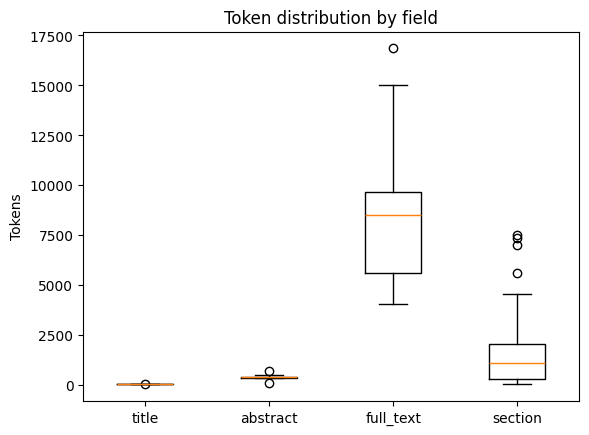

In [77]:
plot_token_boxplot(df_tokens);